In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# 1. SETUP THE DATA
# ==========================================
# Create a simple dataset of fruits
data = {
    'Weight': [150,     130,     170,      120,      110,      160],
    'Color':  ['Red',   'Green', 'Orange', 'Yellow', 'Yellow', 'Orange'],
    'Fruit':  ['Apple', 'Apple', 'Orange', 'Banana', 'Banana', 'Orange']
}

df = pd.DataFrame(data)

# Separate Features (X) and Target (y)
X_raw = df[['Weight', 'Color']]
y = df['Fruit']
print(df)

   Weight   Color   Fruit
0     150     Red   Apple
1     130   Green   Apple
2     170  Orange  Orange
3     120  Yellow  Banana
4     110  Yellow  Banana
5     160  Orange  Orange


In [5]:
X = pd.get_dummies(X_raw, columns=['Color'])
print(X)
print("\n")

   Weight  Color_Green  Color_Orange  Color_Red  Color_Yellow
0     150        False         False       True         False
1     130         True         False      False         False
2     170        False          True      False         False
3     120        False         False      False          True
4     110        False         False      False          True
5     160        False          True      False         False




In [6]:
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [7]:
tree_rules = export_text(clf, feature_names=list(X.columns))
print("Train Decision Tree Rules:\n")
print(tree_rules)

Train Decision Tree Rules:

|--- Weight <= 125.00
|   |--- class: Banana
|--- Weight >  125.00
|   |--- Color_Orange <= 0.50
|   |   |--- class: Apple
|   |--- Color_Orange >  0.50
|   |   |--- class: Orange



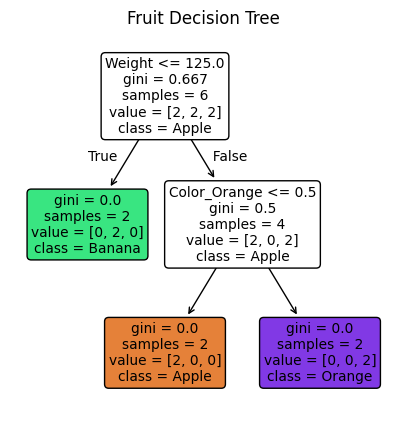

In [11]:
plt.figure(figsize=(5,5))
plot_tree(clf, feature_names=list(X.columns), class_names=list(clf.classes_), filled=True, rounded=True)
plt.title("Fruit Decision Tree")
plt.show()